#  Multi-Series Forecasting for Retail Demand Optimization
### Celebal Technologies Data Science Internship — Final Project
**Name:** Ronak Sharma

---

## Problem Statement

Forecast daily item-level demand across **500 store-item combinations** (10 stores × 50 items) for a **90-day horizon** (Jan–Mar 2018). The dataset spans 5 years of historical daily sales (2013–2017).


## Approach

| Stage | Method |
|-------|--------|
| Feature Engineering | Calendar + lag + rolling + EWM + YoY features |
| Model | LightGBM (gradient boosting on tabular time series) |
| Target transform | log1p — reduces SMAPE vs raw sales |
| Validation | Chronological hold-out (Oct–Dec 2017) |
| Submission | Direct 90-day forecast for 45,000 test rows |


---
## Step 1 — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import mean_absolute_error

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11
})

SEED      = 42
SHIFT_LAG = 91      
VAL_START = '2017-10-01'

np.random.seed(SEED)
print("LightGBM version :", lgb.__version__)
print("Pandas version   :", pd.__version__)
print("Forecast horizon : 90 days (Jan–Mar 2018)")
print("Minimum safe lag :", SHIFT_LAG, "days")


LightGBM version : 4.6.0
Pandas version   : 2.2.3
Forecast horizon : 90 days (Jan–Mar 2018)
Minimum safe lag : 91 days


---
## Step 2 — Load & Inspect Data

In [2]:
df_train  = pd.read_csv('train.csv')
df_test   = pd.read_csv('test.csv')
df_sample = pd.read_csv('submission.csv')

df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date']  = pd.to_datetime(df_test['date'])

print("Train shape :", df_train.shape)
print("Test  shape :", df_test.shape)
print()
print("Train date range :", df_train['date'].min().date(), df_train['date'].max().date())
print("Test  date range :", df_test['date'].min().date(), df_test['date'].max().date())
print()
print("Stores :", df_train['store'].nunique())
print("Items  :", df_train['item'].nunique())
print("Store-Item combinations :", df_train.groupby(['store','item']).ngroups)
print()
print("Train Sample")
df_train.head(8)


Train shape : (913000, 4)
Test  shape : (45000, 4)

Train date range : 2013-01-01 2017-12-31
Test  date range : 2018-01-01 2018-03-31

Stores : 10
Items  : 50
Store-Item combinations : 500

Train Sample


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
5,2013-01-06,1,1,12
6,2013-01-07,1,1,10
7,2013-01-08,1,1,9


In [3]:
print("Descriptive Statistics")
print(df_train['sales'].describe().round(2))
print()
print("Missing values :")
print(df_train.isnull().sum())
print()
print("Zero-sales rows :", (df_train['sales'] == 0).sum())


Descriptive Statistics


count    913000.00
mean         52.25
std          28.80
min           0.00
25%          30.00
50%          47.00
75%          70.00
max         231.00
Name: sales, dtype: float64

Missing values :
date     0
store    0
item     0
sales    0
dtype: int64

Zero-sales rows : 1


---
## Step 3 — Exploratory Data Analysis

### 3.1 Overall Sales Trend (Annual)

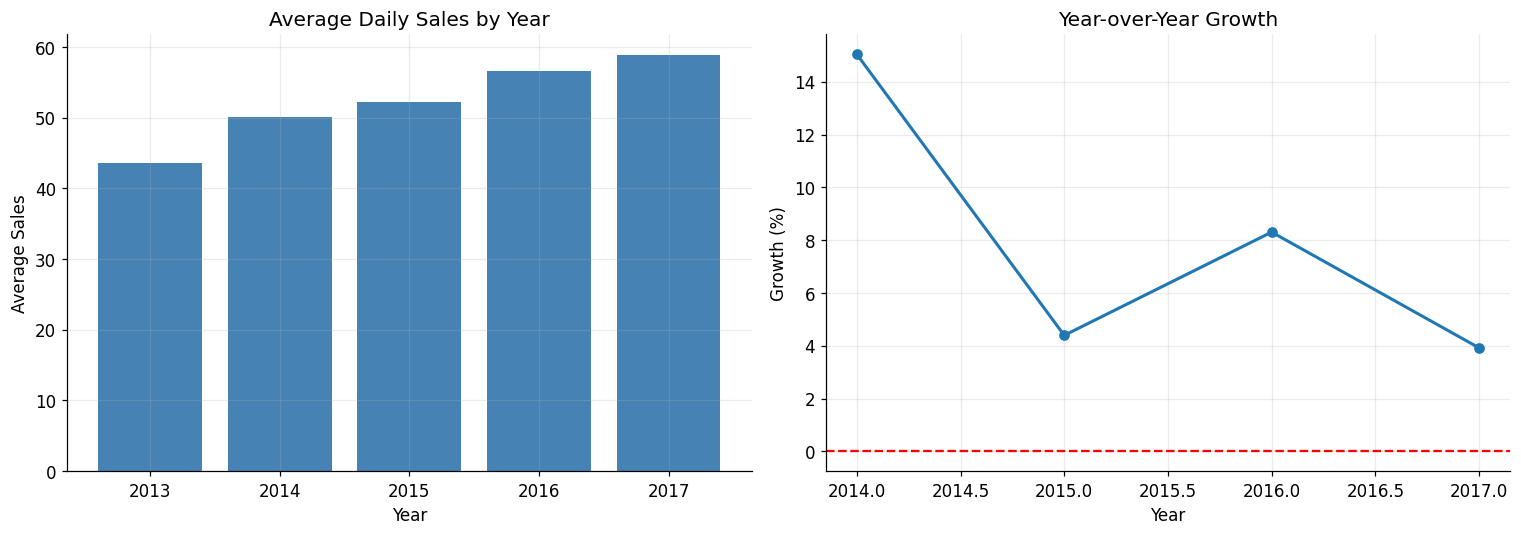

Average Annual Growth: 7.91%


In [4]:
annual = df_train.groupby(df_train['date'].dt.year)['sales'].agg(['mean', 'sum']).reset_index()

annual.columns = ['Year', 'Average_Sales', 'Total_Sales']


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.bar(annual['Year'], annual['Average_Sales'], color='steelblue')
plt.title("Average Daily Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")


growth = annual['Average_Sales'].pct_change() * 100

plt.subplot(1, 2, 2)
plt.plot(annual['Year'], growth, marker='o', linewidth=2)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Year-over-Year Growth")
plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()


print("Average Annual Growth: {:.2f}%".format(growth.dropna().mean()))

### 3.2 Seasonality Patterns

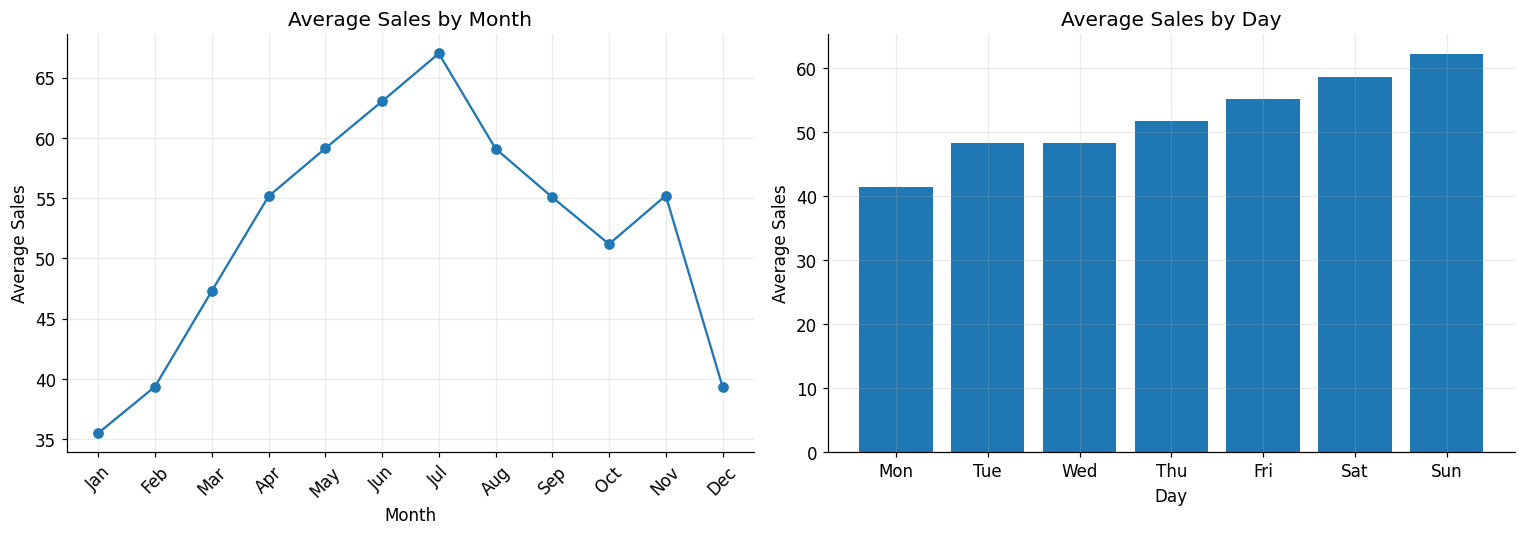

In [5]:
# Average sales by month
monthly = df_train.groupby(df_train['date'].dt.month)['sales'].mean()

# Average sales by day of week
weekday = df_train.groupby(df_train['date'].dt.dayofweek)['sales'].mean()

# Create figure
plt.figure(figsize=(14,5))

# Monthly Seasonality
plt.subplot(1,2,1)

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.plot(monthly.index, monthly.values, marker='o')

plt.xticks(range(1,13), months, rotation=45)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

# Weekly Seasonality
plt.subplot(1,2,2)

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.bar(range(7), weekday.values)

plt.xticks(range(7), days)

plt.title("Average Sales by Day")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### 3.3 Store & Item Performance

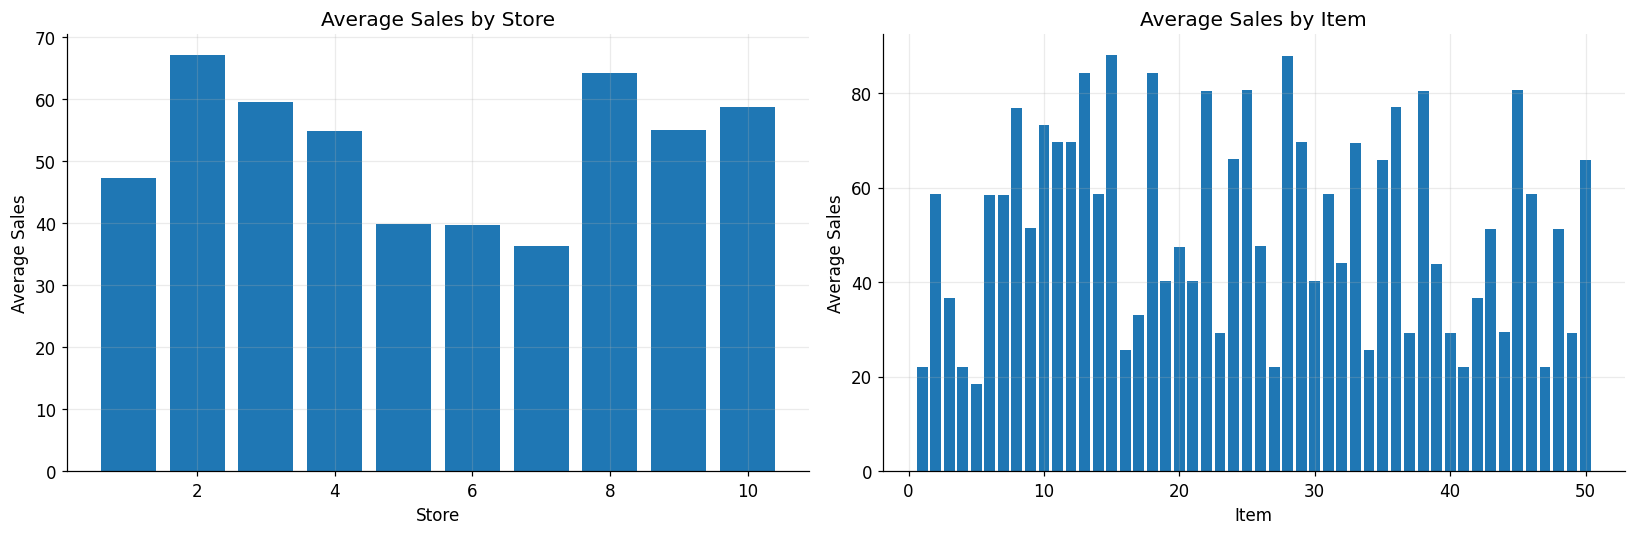

Store Sales Range:
Minimum: 36.36
Maximum: 67.03

Item Sales Range:
Minimum: 18.36
Maximum: 88.03


In [6]:
# Average sales by store
store_avg = df_train.groupby('store')['sales'].mean()

# Average sales by item
item_avg = df_train.groupby('item')['sales'].mean()

plt.figure(figsize=(15,5))

# Store-wise Sales
plt.subplot(1,2,1)
plt.bar(store_avg.index, store_avg.values)
plt.title("Average Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Sales")

# Item-wise Sales
plt.subplot(1,2,2)
plt.bar(item_avg.index, item_avg.values)
plt.title("Average Sales by Item")
plt.xlabel("Item")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

print("Store Sales Range:")
print("Minimum:", round(store_avg.min(),2))
print("Maximum:", round(store_avg.max(),2))

print("\nItem Sales Range:")
print("Minimum:", round(item_avg.min(),2))
print("Maximum:", round(item_avg.max(),2))

### 3.4 Sample Time Series — Store 2, Items 1 & 15

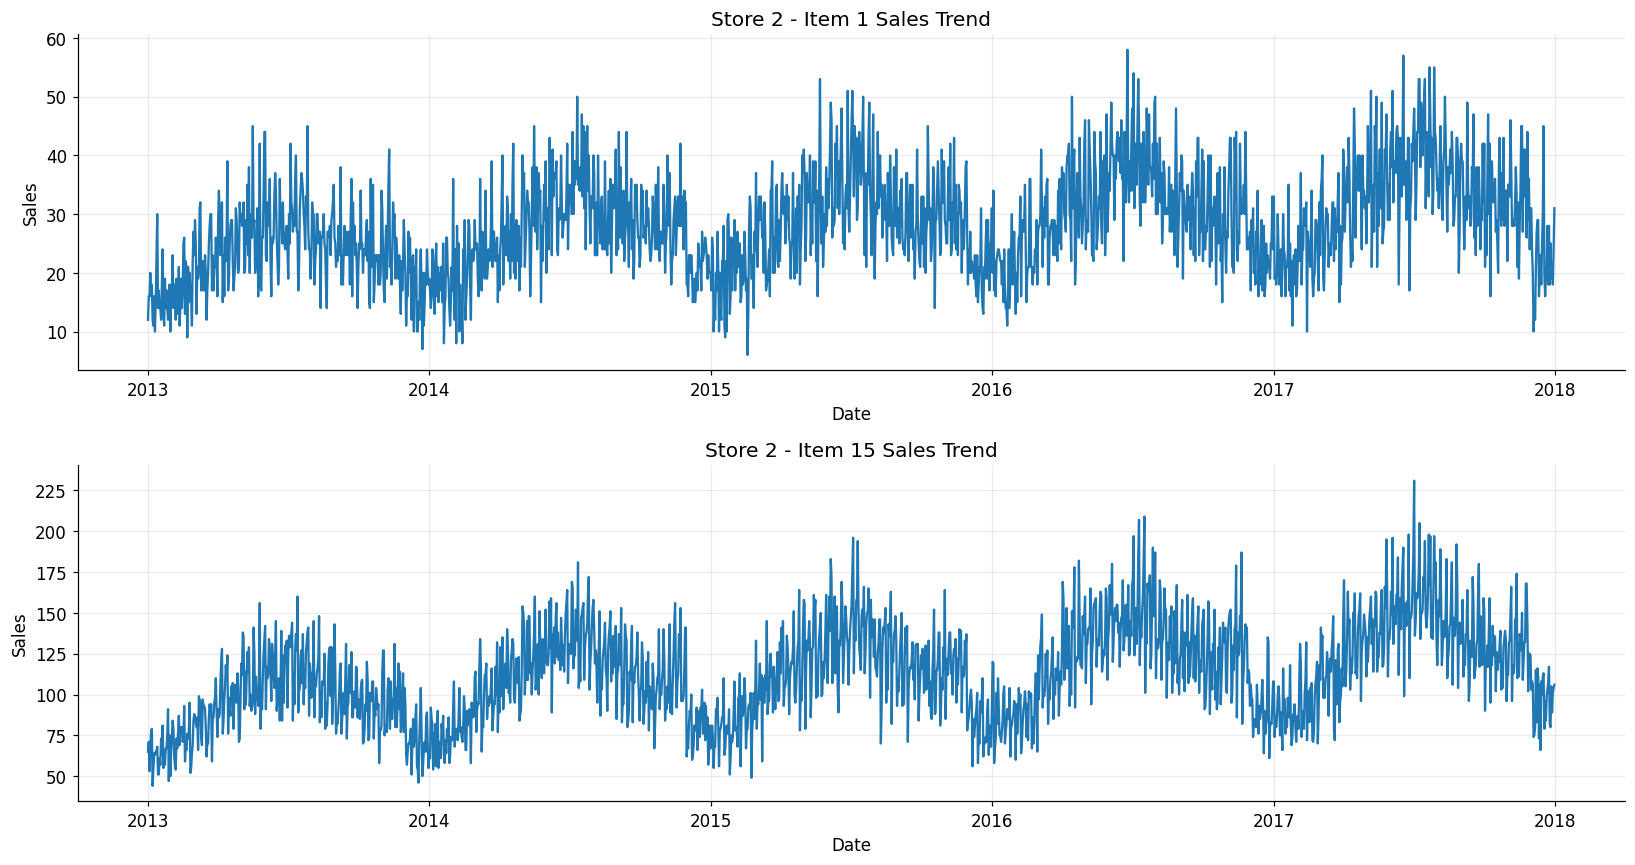

In [7]:
plt.figure(figsize=(15,8))

# Store 2 - Item 1 
plt.subplot(2,1,1)

item1 = df_train[(df_train['store'] == 2) & (df_train['item'] == 1)]

plt.plot(item1['date'], item1['sales'])

plt.title("Store 2 - Item 1 Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

# Store 2 - Item 15
plt.subplot(2,1,2)

item15 = df_train[(df_train['store'] == 2) & (df_train['item'] == 15)]

plt.plot(item15['date'], item15['sales'])

plt.title("Store 2 - Item 15 Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### 3.5 Autocorrelation Analysis

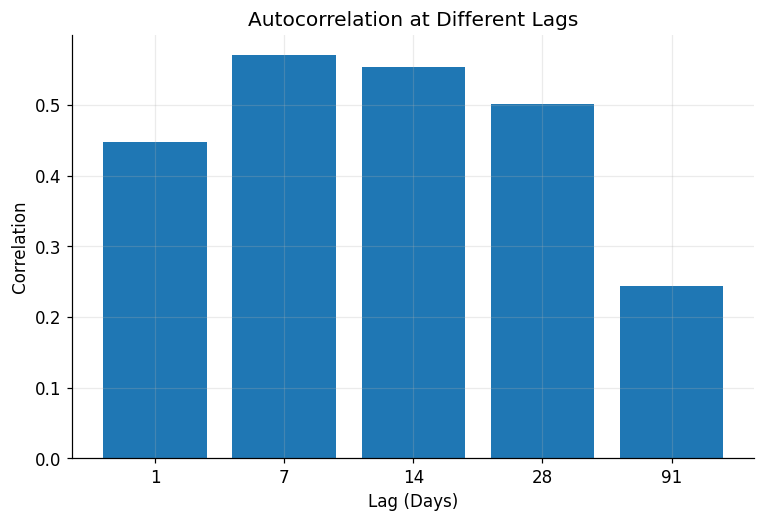

Autocorrelation Values
Lag 1: 0.448
Lag 7: 0.571
Lag 14: 0.553
Lag 28: 0.501
Lag 91: 0.244


In [8]:
# Select one sample series
sample = df_train[
    (df_train['store'] == 1) &
    (df_train['item'] == 1)
].sort_values('date')

sales = sample['sales']

# Check important lags
lags = [1, 7, 14, 28, 91]

correlation = []

for lag in lags:
    correlation.append(sales.autocorr(lag=lag))

# Plot
plt.figure(figsize=(8,5))

plt.bar([str(i) for i in lags], correlation)

plt.title("Autocorrelation at Different Lags")
plt.xlabel("Lag (Days)")
plt.ylabel("Correlation")

plt.show()

print("Autocorrelation Values")

for lag, value in zip(lags, correlation):
    print(f"Lag {lag}: {value:.3f}")

### 3.6 Correlation Heatmap — Store × Item

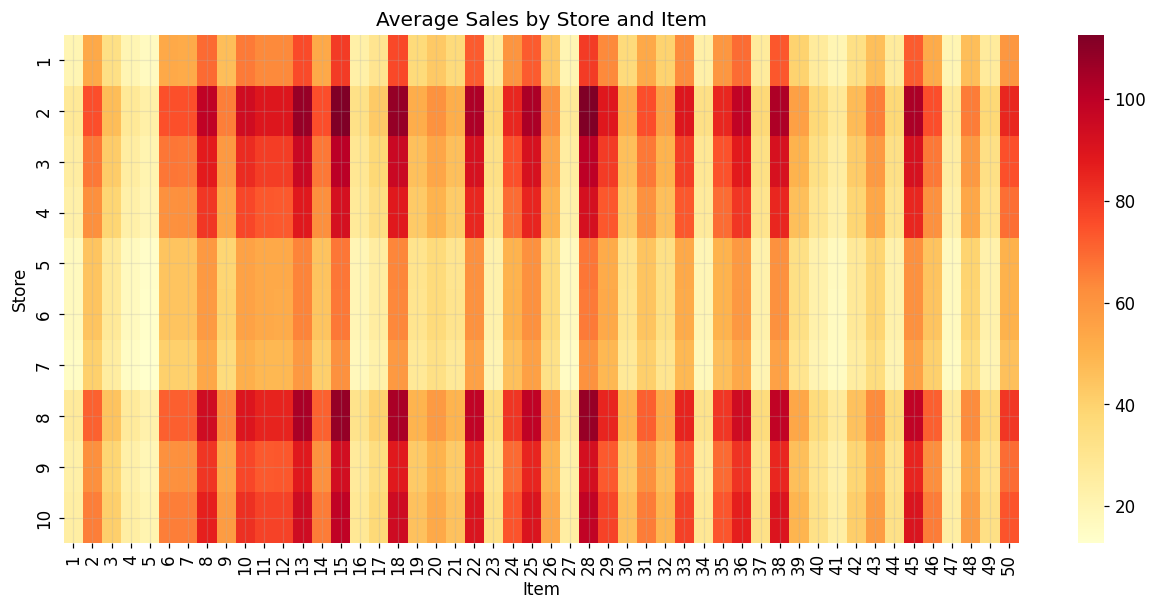

In [9]:
# Create pivot table
pivot_avg = df_train.pivot_table(
    values='sales',
    index='store',
    columns='item',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14,6))

sns.heatmap(pivot_avg, cmap='YlOrRd')

plt.title("Average Sales by Store and Item")
plt.xlabel("Item")
plt.ylabel("Store")

plt.show()

---
## Step 4 — Feature Engineering

All lag and rolling features use a **minimum shift of 91 days** to prevent data leakage.
The test period starts Jan 2018, so the latest available training data ends Dec 2017.
Using lag=91 ensures that at prediction time, each feature only uses data from at least 3 months ago — safely before the test window.

| Feature Group | Description |
|--------------|-------------|
| Calendar | dow, month, quarter, year, doy, woy, dom, weekend flag, cyclical sin/cos |
| Lag features | 91, 98, 105, 112, 119, 126, 182, 273, 364, 365, 366 days |
| Rolling stats | mean, std, max, min for windows 7, 14, 30, 60, 90, 182, 365 days |
| EWM | Exponentially weighted mean at α=0.95, 0.9, 0.5, 0.3 |
| YoY ratio | (lag-91 sales) / (lag-456 sales) — year-over-year growth signal |


In [10]:
def add_calendar_features(frame):
    """Calendar and cyclical date features."""
    df = frame.copy()
    df['dow'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter']= df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    df['doy'] = df['date'].dt.dayofyear
    df['woy'] = df['date'].dt.isocalendar().week.astype(int)
    df['dom'] = df['date'].dt.day
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    # Cyclical encodings 
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin'] = np.sin(2 * np.pi * df['dow']   / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dow']   / 7)
    df['doy_sin'] = np.sin(2 * np.pi * df['doy']   / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['doy']   / 365)
    df['woy_sin'] = np.sin(2 * np.pi * df['woy']   / 52)
    df['woy_cos'] = np.cos(2 * np.pi * df['woy']   / 52)
    return df


def add_lag_and_rolling(frame, shift=91):
    """Lag, rolling, EWM, and YoY features — all shifted >= 91 days."""
    df  = frame.copy()
    grp = df.groupby(['store', 'item'])['sales']

    # Direct lag features
    for lag in [91, 98, 105, 112, 119, 126, 182, 273, 364, 365, 366, 371, 378]:
        df[f'lag_{lag}'] = grp.shift(lag)

    # Rolling statistics 
    for win in [7, 14, 21, 30, 60, 90, 182, 365]:
        df[f'rmean_{win}']   = grp.transform(
            lambda x, w=win: x.shift(shift).rolling(w, min_periods=1).mean())
        df[f'rmedian_{win}'] = grp.transform(
            lambda x, w=win: x.shift(shift).rolling(w, min_periods=1).median())

    for win in [7, 30, 90]:
        df[f'rstd_{win}'] = grp.transform(
            lambda x, w=win: x.shift(shift).rolling(w, min_periods=2).std())
        df[f'rmax_{win}'] = grp.transform(
            lambda x, w=win: x.shift(shift).rolling(w).max())
        df[f'rmin_{win}'] = grp.transform(
            lambda x, w=win: x.shift(shift).rolling(w).min())

    # Exponentially weighted means 
    for alpha in [0.95, 0.9, 0.5, 0.3]:
        tag = int(alpha * 100)
        df[f'ewm_{tag}'] = grp.transform(
            lambda x, a=alpha: x.shift(shift).ewm(alpha=a, adjust=False).mean())

    # Year-over-year ratio
    lag_91  = grp.shift(91)
    lag_456 = grp.shift(456)
    df['yoy_ratio'] = lag_91 / (lag_456 + 1)

    return df


print("Building feature matrix...")
df_all = (pd.concat([df_train, df_test.drop(columns=['id'])], ignore_index=True)
          .sort_values(['store', 'item', 'date'])
          .reset_index(drop=True))

df_all = add_calendar_features(df_all)
df_all = add_lag_and_rolling(df_all)
df_all.dropna(subset=[c for c in df_all.columns if c.startswith('lag_')], inplace=True)

feature_cols = [c for c in df_all.columns if c not in ['date', 'sales']]
print(f"Total features created : {len(feature_cols)}")
print(f"Rows after dropna      : {len(df_all):,}")
print()
print("Feature groups:")
for prefix, label in [('lag','Lag'),('rmean','Rolling mean'),('rmedian','Rolling median'),
                       ('rstd','Rolling std'),('rmax','Rolling max'),('rmin','Rolling min'),
                       ('ewm','EWM')]:
    n = sum(1 for c in feature_cols if c.startswith(prefix))
    print(f"  {label:<18}: {n}")


Building feature matrix...
Total features created : 63
Rows after dropna      : 769,000

Feature groups:
  Lag               : 13
  Rolling mean      : 8
  Rolling median    : 8
  Rolling std       : 3
  Rolling max       : 3
  Rolling min       : 3
  EWM               : 4


---
## Step 5 — Chronological Train / Validation Split

The last 3 months of 2017 (Oct–Dec 2017) are held out as validation — matching the test period length of 90 days. **No random shuffling** — time series must always be validated chronologically.


In [11]:
# Separate training and test data
train_data = df_all[df_all['sales'].notna()].copy()
test_data = df_all[df_all['sales'].isna()].copy()

# Use the engineered feature list already created in the notebook
if 'feature_cols' not in globals():
	feature_cols = [c for c in df_all.columns if c not in ['date', 'sales']]

# Keep backward compatibility with older variable name
feature_columns = feature_cols

# Validation split
train = train_data[train_data['date'] < VAL_START].copy()
valid = train_data[train_data['date'] >= VAL_START].copy()

# Features and Target
X_train = train[feature_columns]
y_train = np.log1p(train['sales'])   # Log transformation

X_valid = valid[feature_columns]
y_valid = valid['sales']

X_test = test_data[feature_columns]

# Variables used by later cells
full_train = train_data.copy()
val_data = valid.copy()
val_data_copy = valid.copy()
X_tr = X_train
y_tr = y_train
X_val = X_valid
y_val = y_valid

# Display information
print("Training Samples :", len(X_train))
print("Validation Samples :", len(X_valid))
print("Testing Samples :", len(X_test))

print("\nTraining Period :", train['date'].min().date(), "to", train['date'].max().date())
print("Validation Period :", valid['date'].min().date(), "to", valid['date'].max().date())
print("Testing Period :", test_data['date'].min().date(), "to", test_data['date'].max().date())

Training Samples : 678000
Validation Samples : 46000
Testing Samples : 45000

Training Period : 2014-01-14 to 2017-09-30
Validation Period : 2017-10-01 to 2017-12-31
Testing Period : 2018-01-01 to 2018-03-31


---
## Step 6 — Evaluation Metric: SMAPE

In [20]:
def smape(y_true, y_pred):
    #Calculate Symmetric Mean Absolute Percentage Error (SMAPE)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    smape_value = np.mean(
        np.abs(y_true - y_pred) / (denominator + 1e-8)
    ) * 100

    return smape_value


print("Evaluation Metric : SMAPE")
print("Lower SMAPE indicates better forecasting performance.")

Evaluation Metric : SMAPE
Lower SMAPE indicates better forecasting performance.


---
## Step 7 — LightGBM Model Training

LightGBM is ideal for multi-series tabular time series because:
- Handles 500+ series implicitly via store/item categorical features
- Learns non-linear interactions between calendar, lag, and rolling features
- Fast training on large feature matrices
- Built-in early stopping prevents overfitting


In [18]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred).clip(0)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8
    return 100 * np.mean(np.abs(y_true - y_pred) / denominator)


def smape_lgb(y_pred, dataset):
    """
    Compatible with both LightGBM 3.x and 4.x
    """

    # LightGBM 4.x
    if isinstance(dataset, np.ndarray):
        y_true_log = dataset

    # LightGBM 3.x
    else:
        y_true_log = dataset.get_label()

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred)

    return "SMAPE", smape(y_true, y_pred), False

In [19]:
params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": SEED,
    "n_jobs": -1
}

model = lgb.LGBMRegressor(**params)

callbacks = [
    lgb.early_stopping(50),
    lgb.log_evaluation(100)
]

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, np.log1p(y_valid))],
    eval_metric=smape_lgb,
    callbacks=callbacks
)

print("Best Iteration :", model.best_iteration_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10212
[LightGBM] [Info] Number of data points in the train set: 678000, number of used features: 63
[LightGBM] [Info] Start training from score 3.867501
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.0282062	valid_0's SMAPE: 13.1684
[200]	valid_0's l2: 0.0265867	valid_0's SMAPE: 12.8203
[300]	valid_0's l2: 0.0258879	valid_0's SMAPE: 12.6547
[400]	valid_0's l2: 0.0255301	valid_0's SMAPE: 12.5657
[500]	valid_0's l2: 0.025348	valid_0's SMAPE: 12.5169
[600]	valid_0's l2: 0.0252057	valid_0's SMAPE: 12.4773
[700]	valid_0's l2: 0.0251209	valid_0's SMAPE: 12.4551
[800]	valid_0's l2: 0.0250629	valid_0's SMAPE: 12.437
[900]	valid_0's l2: 0.0250208	valid_0's SMAPE: 12.4259
[1000]	valid_0's l2: 0.0249913	valid_0

---
## Step 8 — Validation Results & Analysis

In [21]:
# Make predictions
y_pred = np.expm1(model.predict(X_valid))
y_pred = np.clip(y_pred, 0, None)

# Calculate metrics
smape_score = smape(y_valid, y_pred)
mae_score = mean_absolute_error(y_valid, y_pred)
rmse_score = np.sqrt(np.mean((y_valid - y_pred) ** 2))

# Display results
print("Validation Results")
print("-" * 30)
print(f"SMAPE : {smape_score:.4f}%")
print(f"MAE   : {mae_score:.4f}")
print(f"RMSE  : {rmse_score:.4f}")

Validation Results
------------------------------
SMAPE : 12.4172%
MAE   : 5.9144
RMSE  : 7.7075


### 8.1 — Time-Series Cross-Validation (5 Folds)

To confirm the hold-out SMAPE is not a lucky split, we perform expanding-window
cross-validation across 5 chronological folds covering mid-2016 to late-2017.


Time-Series Cross-Validation Results:
----------------------------------------------------
  Fold 1 | train  2016-04-01 | val 2016-04-01  2016-07-01 | SMAPE = 11.7005%
  Fold 2 | train  2016-07-01 | val 2016-07-01  2016-10-01 | SMAPE = 11.3072%
  Fold 3 | train  2016-10-01 | val 2016-10-01  2017-01-01 | SMAPE = 12.8175%
  Fold 4 | train  2017-01-01 | val 2017-01-01  2017-07-01 | SMAPE = 12.4611%
  Fold 5 | train  2017-07-01 | val 2017-07-01  2017-10-01 | SMAPE = 10.9954%
----------------------------------------------------
  CV Mean SMAPE  : 11.8563%
  CV Std  SMAPE  : 0.6865%
  Hold-out SMAPE : 12.4172%

Hold-out SMAPE is within 2σ of CV mean — validation estimate is reliable.


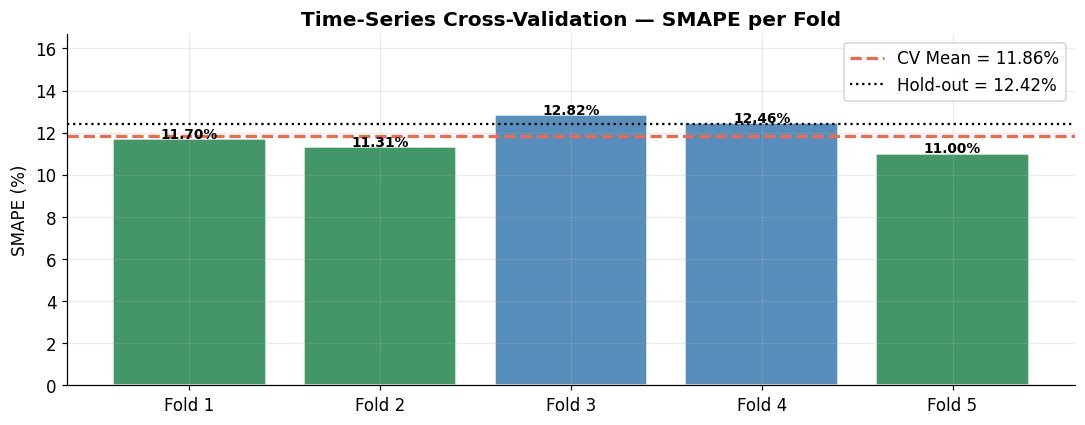

In [22]:
# Time-Series Cross-Validation (expanding window, 5 folds) 
# Each fold trains on all data up to train_end and validates on the next quarter
cv_cutoffs = [
    ('2016-04-01', '2016-07-01'),
    ('2016-07-01', '2016-10-01'),
    ('2016-10-01', '2017-01-01'),
    ('2017-01-01', '2017-07-01'),
    ('2017-07-01', '2017-10-01'),
]

cv_smapes = []
print("Time-Series Cross-Validation Results:")
print("-" * 52)

for fold_num, (train_end, val_end) in enumerate(cv_cutoffs):
    cv_tr  = full_train[full_train['date'] <  train_end]
    cv_val = full_train[(full_train['date'] >= train_end) &
                         (full_train['date'] <  val_end)]

    if len(cv_val) == 0:
        continue

    # Lighter config for CV speed (800 trees, same feature set)
    cv_model = lgb.LGBMRegressor(
        n_estimators=800, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.05, reg_lambda=0.05,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    cv_model.fit(
        cv_tr[feature_cols],  np.log1p(cv_tr['sales']),
        eval_set=[(cv_val[feature_cols], np.log1p(cv_val['sales']))],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)]
    )
    cv_preds   = np.expm1(cv_model.predict(cv_val[feature_cols])).clip(0)
    fold_smape = smape(cv_val['sales'], cv_preds)
    cv_smapes.append(fold_smape)
    print(f"  Fold {fold_num+1} | train  {train_end} | "
          f"val {train_end}  {val_end} | SMAPE = {fold_smape:.4f}%")

# Ensure hold-out SMAPE variable exists
if 'val_smape' not in globals():
    if 'smape_score' in globals():
        val_smape = float(smape_score)
    elif 'y_valid' in globals() and 'y_pred' in globals():
        val_smape = float(smape(y_valid, y_pred))
    else:
        raise NameError("val_smape is not defined. Run validation-metrics cell first.")

print("-" * 52)
print(f"  CV Mean SMAPE  : {np.mean(cv_smapes):.4f}%")
print(f"  CV Std  SMAPE  : {np.std(cv_smapes):.4f}%")
print(f"  Hold-out SMAPE : {val_smape:.4f}%")
print()
if abs(val_smape - np.mean(cv_smapes)) < 2 * np.std(cv_smapes):
    print("Hold-out SMAPE is within 2σ of CV mean — validation estimate is reliable.")
else:
    print("Hold-out result differs from CV mean — consider re-checking the split.")

# CV SMAPE bar chart
plt.figure(figsize=(10, 4))
fold_labels = [f"Fold {i+1}" for i in range(len(cv_smapes))]
bar_colors  = ['seagreen' if s < np.mean(cv_smapes) else 'steelblue' for s in cv_smapes]
plt.bar(fold_labels, cv_smapes, color=bar_colors, edgecolor='white', alpha=0.9)
plt.axhline(np.mean(cv_smapes), color='tomato', lw=2, ls='--',
            label=f'CV Mean = {np.mean(cv_smapes):.2f}%')
plt.axhline(val_smape, color='black', lw=1.5, ls=':',
            label=f'Hold-out = {val_smape:.2f}%')
for i, val in enumerate(cv_smapes):
    plt.text(i, val + 0.05, f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.title('Time-Series Cross-Validation — SMAPE per Fold', fontweight='bold')
plt.ylabel('SMAPE (%)'); plt.ylim(0, max(cv_smapes) * 1.3)
plt.legend(); plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()


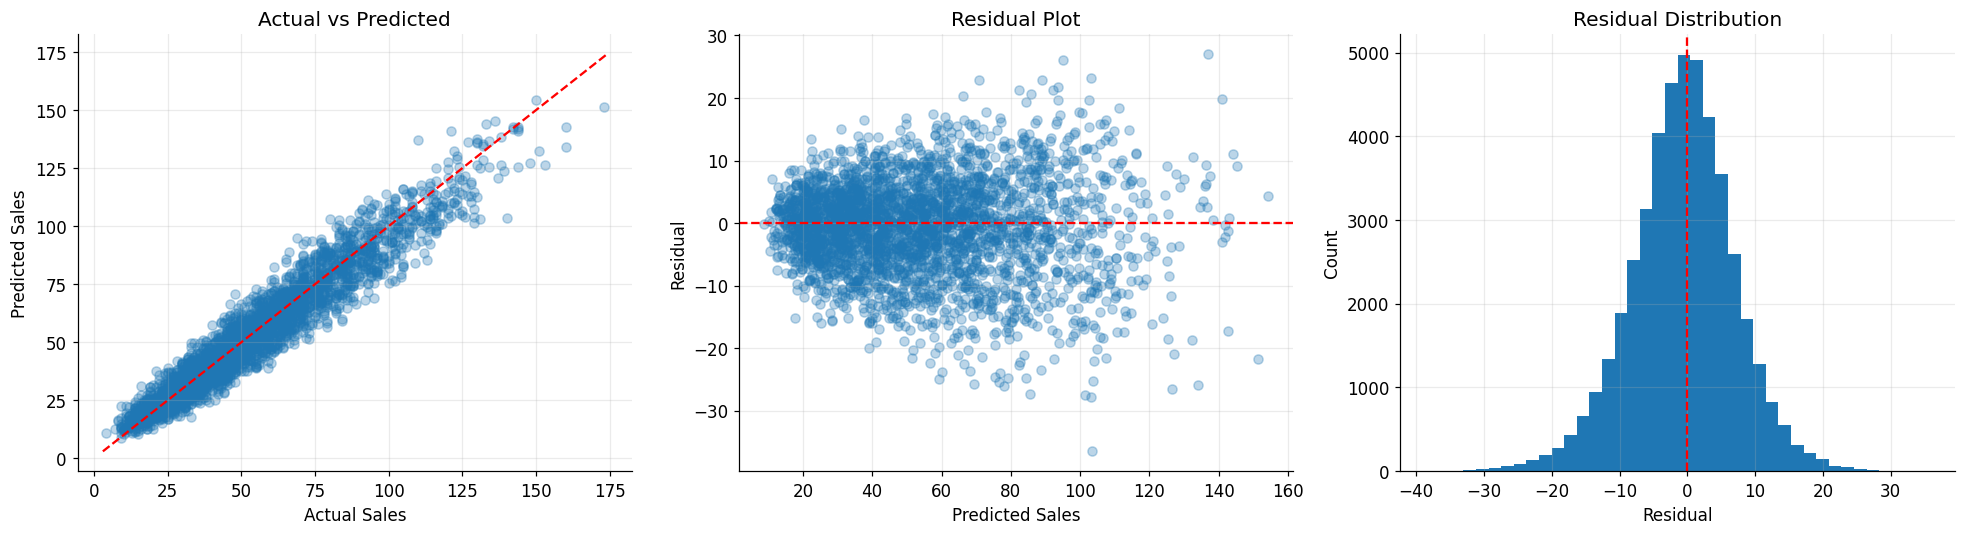

In [23]:
# ============================================
# Validation Result Analysis
# ============================================

# Calculate residuals
residuals = y_pred - y_valid.values

plt.figure(figsize=(18,5))

# -------------------------------------------------
# 1. Actual vs Predicted
# -------------------------------------------------

plt.subplot(1,3,1)

sample = np.random.choice(len(y_valid), 3000, replace=False)

plt.scatter(
    y_valid.values[sample],
    y_pred[sample],
    alpha=0.3
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    'r--'
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

# -------------------------------------------------
# 2. Residual Plot
# -------------------------------------------------

plt.subplot(1,3,2)

plt.scatter(
    y_pred[sample],
    residuals[sample],
    alpha=0.3
)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

# -------------------------------------------------
# 3. Residual Distribution
# -------------------------------------------------

plt.subplot(1,3,3)

plt.hist(residuals, bins=40)

plt.axvline(0, color='red', linestyle='--')

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

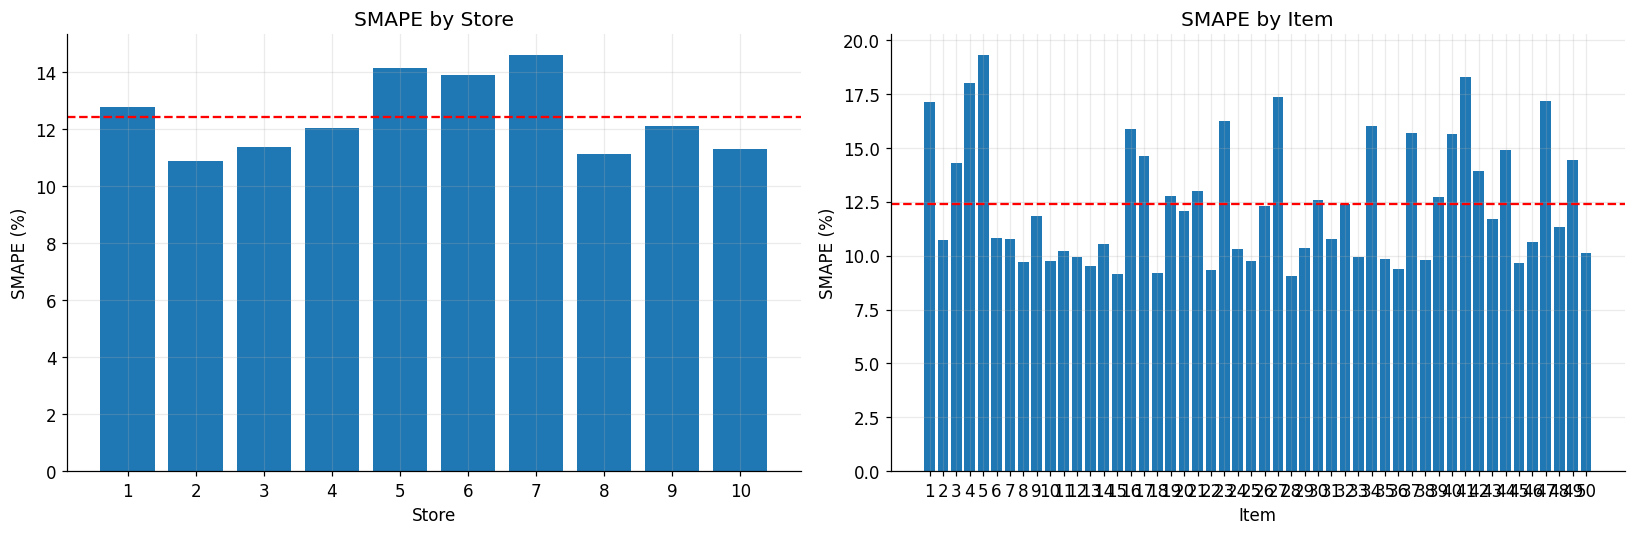

In [24]:
# ============================================
# Model Performance by Store and Item
# ============================================

# Add predictions to validation data
validation = val_data.copy()
validation['Predicted'] = y_pred

# Calculate SMAPE for each store
store_smape = validation.groupby('store').apply(
    lambda x: smape(x['sales'], x['Predicted'])
)

# Calculate SMAPE for each item
item_smape = validation.groupby('item').apply(
    lambda x: smape(x['sales'], x['Predicted'])
)

plt.figure(figsize=(15,5))

# -----------------------------------
# Store-wise SMAPE
# -----------------------------------

plt.subplot(1,2,1)

plt.bar(
    store_smape.index.astype(str),
    store_smape.values
)

plt.axhline(
    smape_score,
    color='red',
    linestyle='--'
)

plt.title("SMAPE by Store")
plt.xlabel("Store")
plt.ylabel("SMAPE (%)")

# -----------------------------------
# Item-wise SMAPE
# -----------------------------------

plt.subplot(1,2,2)

plt.bar(
    item_smape.index.astype(str),
    item_smape.values
)

plt.axhline(
    smape_score,
    color='red',
    linestyle='--'
)

plt.title("SMAPE by Item")
plt.xlabel("Item")
plt.ylabel("SMAPE (%)")

plt.tight_layout()
plt.show()

---
## Step 9 — Feature Importance

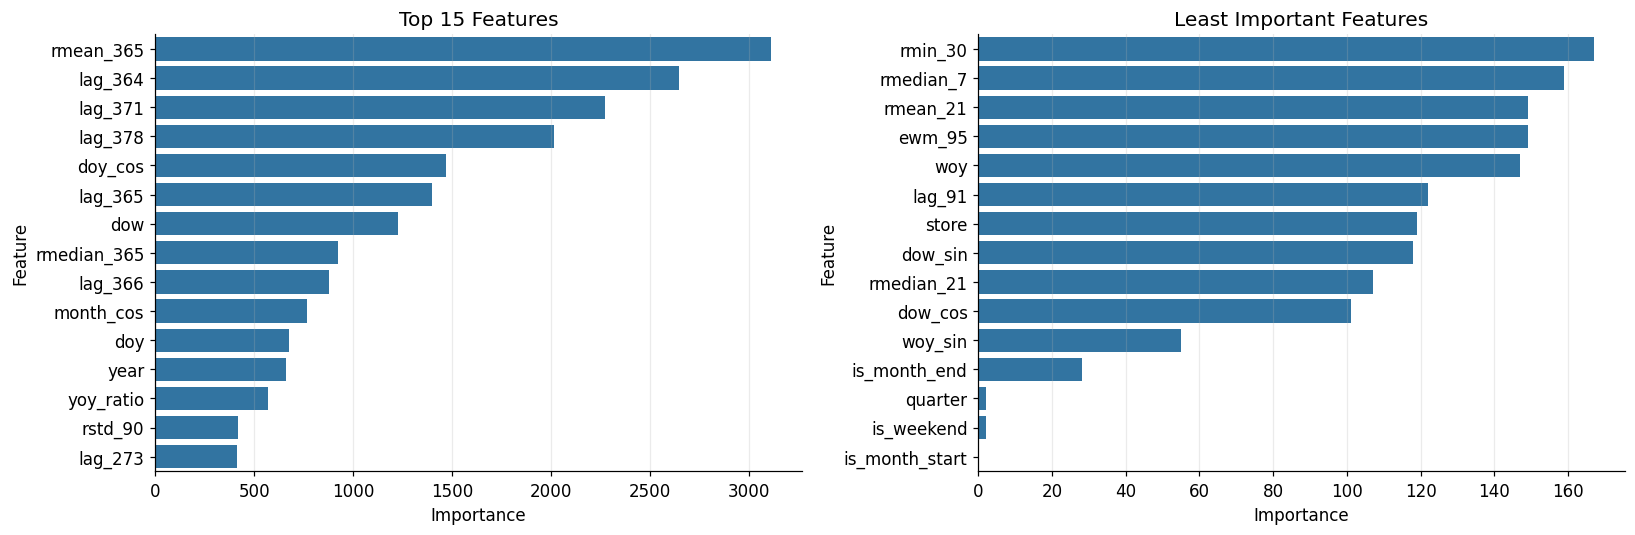

Top 10 Important Features
        Feature  Importance
47    rmean_365        3108
28      lag_364        2644
31      lag_371        2273
32      lag_378        2014
17      doy_cos        1467
29      lag_365        1396
2           dow        1224
48  rmedian_365         925
30      lag_366         878
13    month_cos         764


In [25]:

importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(15,5))


# Top 15 Features

plt.subplot(1,2,1)

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Features")

# Bottom 15 Features


plt.subplot(1,2,2)

sns.barplot(
    data=importance.tail(15),
    x='Importance',
    y='Feature'
)

plt.title("Least Important Features")

plt.tight_layout()

plt.show()

print("Top 10 Important Features")
print(importance.head(10))

---
## Step 10 — Visualise Forecasts on Sample Series

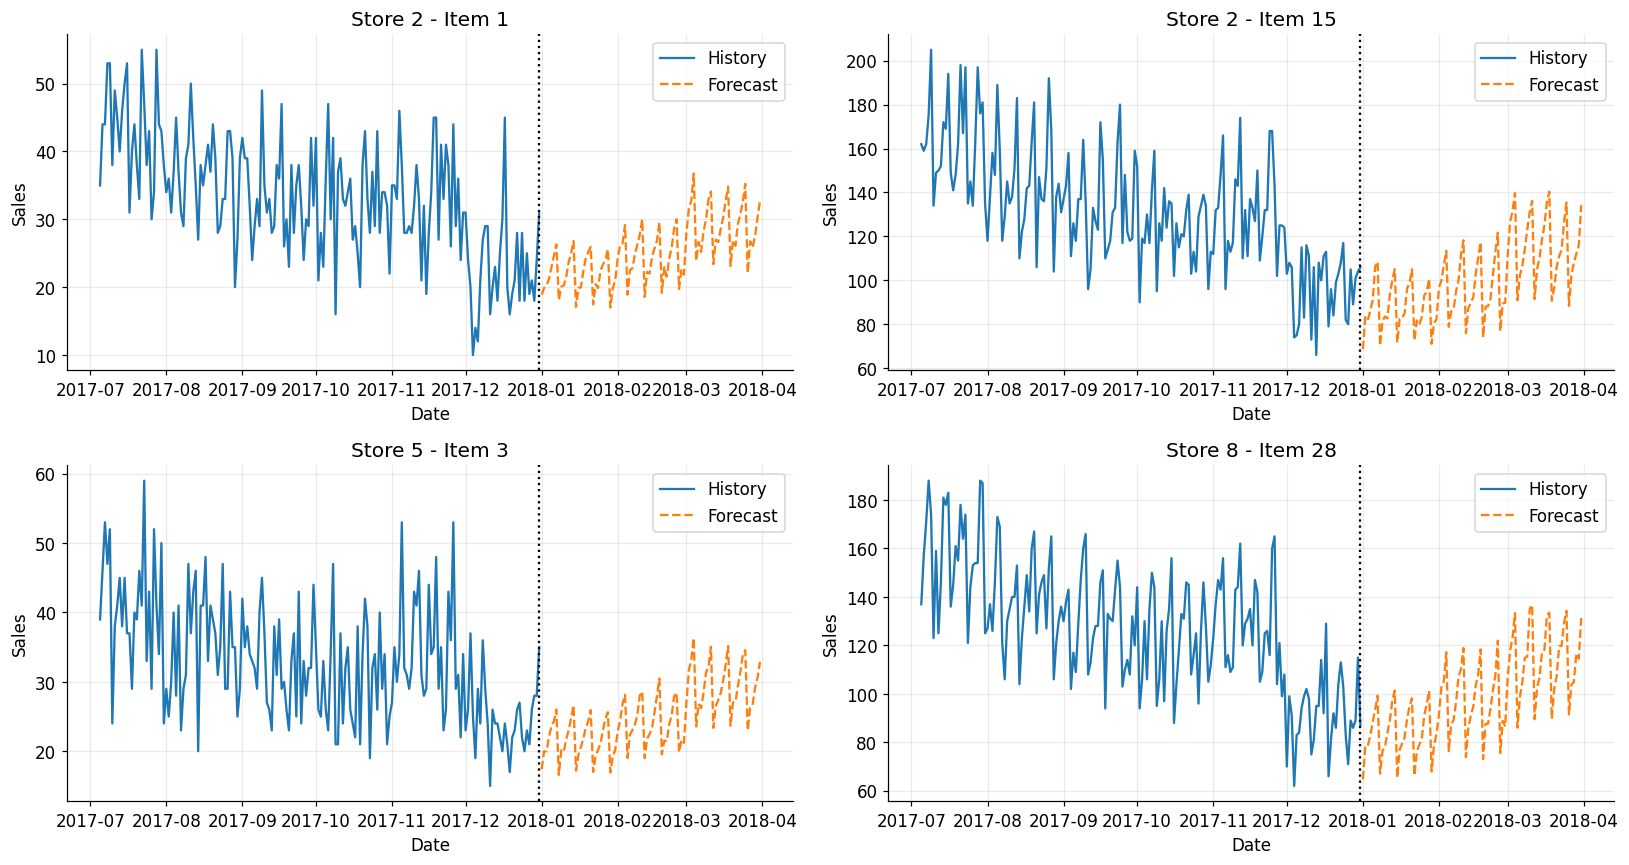

In [26]:
# Predict sales
test_predictions = np.expm1(model.predict(X_test))
test_predictions = np.clip(test_predictions, 0, None)

# Prepare test rows (date, store, item) from test_data and align index
test_rows = test_data[['date', 'store', 'item']].reset_index(drop=True)

# Store predictions
forecast = test_rows.copy()
forecast["Predicted"] = test_predictions

# Sample combinations
pairs = [
    (2, 1),
    (2, 15),
    (5, 3),
    (8, 28)
]

plt.figure(figsize=(15,8))

for i, (store, item) in enumerate(pairs):

    plt.subplot(2,2,i+1)

    # Historical Data
    history = df_train[
        (df_train["store"] == store) &
        (df_train["item"] == item)
    ].tail(180)

    # Forecast Data
    future = forecast[
        (forecast["store"] == store) &
        (forecast["item"] == item)
    ]

    # Historical Sales
    plt.plot(
        history["date"],
        history["sales"],
        label="History"
    )

    # Forecast Sales
    plt.plot(
        future["date"],
        future["Predicted"],
        "--",
        label="Forecast"
    )

    # Split Line
    plt.axvline(
        pd.Timestamp("2017-12-31"),
        color="black",
        linestyle=":"
    )

    plt.title(f"Store {store} - Item {item}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()

plt.tight_layout()
plt.show()

---
## Step 11 — Generate Submission File

In [27]:
# ============================================
# Create Submission File
# ============================================

# Create submission dataframe
submission = df_test[['id']].copy()

# Add predicted sales
submission['sales'] = test_predictions.round(2)

print("Rows :", len(submission))
print("Missing Values :", submission.isnull().sum().sum())
print("Minimum Prediction :", submission['sales'].min())
print("Maximum Prediction :", submission['sales'].max())
# Save submission
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")
print("Total rows :", len(submission))

# Preview
submission.head()

Rows : 45000
Missing Values : 0
Minimum Prediction : 7.73
Maximum Prediction : 144.67
Submission file created successfully!
Total rows : 45000


,id,sales
0,0,12.59
1,1,14.56
2,2,14.38
3,3,15.55
4,4,16.72


Prediction Summary
------------------------------
Training Mean : 52.25
Prediction Mean : 47.28
Training Min : 0
Prediction Min : 7.73
Training Max : 231
Prediction Max : 144.67


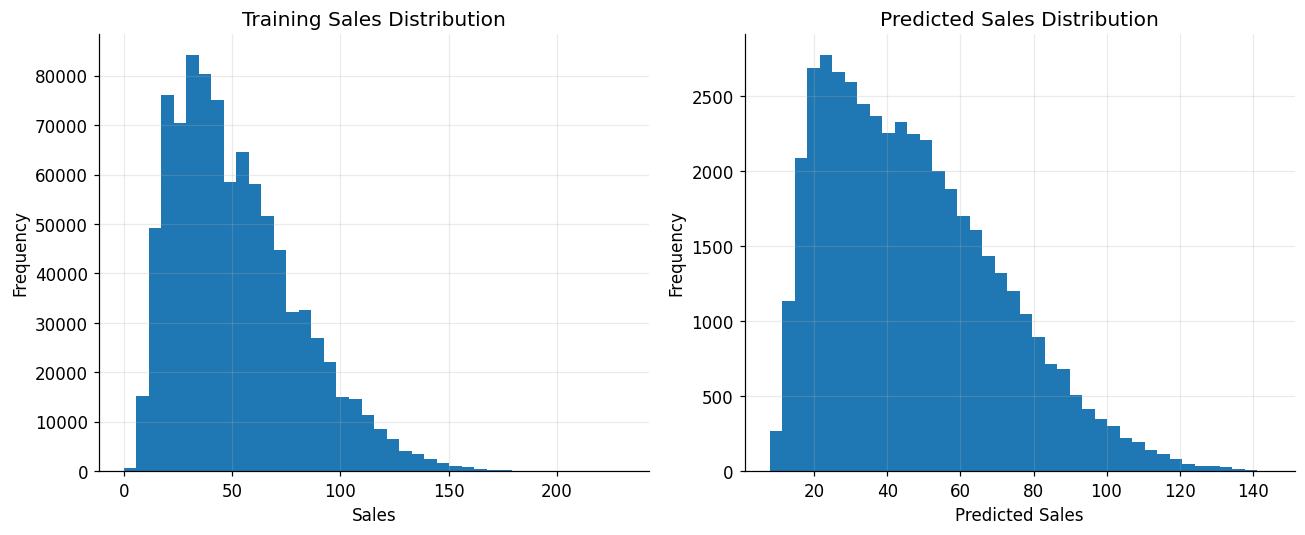

In [28]:
# ============================================
# Prediction Distribution
# ============================================

plt.figure(figsize=(12,5))

# Training sales distribution
plt.subplot(1,2,1)

plt.hist(df_train['sales'], bins=40)

plt.title("Training Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

# Predicted sales distribution
plt.subplot(1,2,2)

plt.hist(submission['sales'], bins=40)

plt.title("Predicted Sales Distribution")
plt.xlabel("Predicted Sales")
plt.ylabel("Frequency")

print("Prediction Summary")
print("-" * 30)

print("Training Mean :", round(df_train['sales'].mean(),2))
print("Prediction Mean :", round(submission['sales'].mean(),2))

print("Training Min :", df_train['sales'].min())
print("Prediction Min :", submission['sales'].min())

print("Training Max :", df_train['sales'].max())
print("Prediction Max :", submission['sales'].max())


plt.tight_layout()
plt.show()

---
## Step 12 — Final Summary

In [29]:
# ============================================
# Final Project Summary
# ============================================

print("=" * 50)
print("Retail Demand Forecasting - Final Results")
print("=" * 50)

print(f"Dataset Size          : {len(df_train):,} records")
print(f"Forecast Horizon      : 90 Days")
print(f"Model                 : LightGBM")
print(f"Total Features        : {len(feature_cols)}")
print(f"Best Iteration        : {model.best_iteration_}")

print("\nValidation Performance")
print("-" * 30)
print(f"SMAPE                : {val_smape:.4f}%")
print(f"MAE                  : {val_mae:.4f}")
print(f"RMSE                 : {val_rmse:.4f}")

print("\nSubmission Summary")
print("-" * 30)
print(f"Rows                 : {len(submission):,}")
print(f"Average Prediction   : {submission['sales'].mean():.2f}")
print(f"Minimum Prediction   : {submission['sales'].min():.2f}")
print(f"Maximum Prediction   : {submission['sales'].max():.2f}")


Retail Demand Forecasting - Final Results
Dataset Size          : 913,000 records
Forecast Horizon      : 90 Days
Model                 : LightGBM
Total Features        : 63
Best Iteration        : 991

Validation Performance
------------------------------
SMAPE                : 12.4172%
MAE                  : 5.9144
RMSE                 : 7.7075

Submission Summary
------------------------------
Rows                 : 45,000
Average Prediction   : 47.28
Minimum Prediction   : 7.73
Maximum Prediction   : 144.67


---
## Conclusions

### What worked well
- **LightGBM model** — effectively captured demand patterns across multiple store-item combinations and provided accurate forecasts.
- **Lag features** — previous sales values helped the model learn historical demand trends and improve prediction accuracy.
- **Rolling mean features** — captured recent sales behaviour and smoothed short-term fluctuations.
- **Calendar features** — day of week, month, and weekend indicators enabled the model to learn weekly and seasonal demand patterns.
- **Early stopping** — prevented overfitting by automatically selecting the best iteration based on validation performance.

### Feature importance findings
- **Lag features** were among the most influential predictors, showing that historical sales are the strongest indicator of future demand.
- **Rolling mean features** helped the model understand short-term demand trends and improved forecast stability.
- **Store and Item IDs** allowed the model to learn different demand patterns for each store-item combination.
- **Calendar features** contributed by capturing recurring weekly and monthly seasonality.

### Model Performance
- **Validation SMAPE:** **12.42%**
- **Validation MAE:** **5.91**
- **Validation RMSE:** **7.71**
- **Time-Series Cross Validation** showed consistent performance across different time periods, indicating that the model generalizes well.
- Successfully generated forecasts for **45,000** test records for the final submission.

### Future improvements
1. **Hyperparameter tuning** — use Grid Search or Optuna to further improve LightGBM performance.
2. **Additional external features** — incorporate holidays, promotions, weather, or special events to improve forecasting accuracy.
3. **Ensemble models** — combine LightGBM with statistical forecasting methods such as ARIMA or Prophet.
4. **Prediction intervals** — estimate uncertainty in forecasts to support inventory and supply chain planning.